In [989]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report,precision_recall_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_val_score,cross_val_predict
dataA = pd.read_csv("A1_dataA.tsv", sep="\t") 
#Check data
print(dataA.head())


         X1        X2        X3        X4        X5  class
0  0.941443  0.739137  0.789515  0.783686  0.165450      1
1  0.903789  0.774421  1.807503 -1.403254  0.531660      1
2  0.988921  0.763048  1.608549  0.354220  0.979188      1
3  0.945123  1.167735  1.140172 -0.749005  0.171429      0
4  0.912966  1.035160  0.548504  0.499823  0.084890      0


In [990]:
dataA_nonscaled=dataA.copy()
#Scale Data
scaler = StandardScaler()
dataA[["X1","X2","X3","X4","X5"]]= scaler.fit_transform(dataA[["X1","X2","X3","X4","X5"]])
dataA

,X1,X2,X3,X4,X5,class
0,-0.044245,-0.418993,0.167519,1.050053,-0.390117,1
1,-1.290281,-0.318720,1.350108,-2.240164,0.522098,1
2,1.526875,-0.351041,1.118985,0.403928,1.636870,1
3,0.077526,0.799023,0.574876,-1.255857,-0.375223,0
4,-0.986605,0.422262,-0.112460,0.622986,-0.590786,0
...,...,...,...,...,...,...
95,-1.185032,-0.824963,1.745305,0.975435,1.056538,0
96,2.472764,0.999420,-0.396257,-1.209475,-0.629725,0
97,0.423208,1.378425,-0.773909,0.123818,1.781680,1
98,-0.955933,0.531518,0.881046,0.767355,-1.293381,0


In [991]:

#Melt for seaborn
dataA_graph = dataA.melt(
    id_vars=dataA.columns[-1],
    value_vars=dataA.columns[:-1],
    var_name="Feature",
    value_name="Value"
)


In [992]:
#We have two classes
# pd.set_option('display.max_rows',None)
# dataA[dataA["class"]==1]

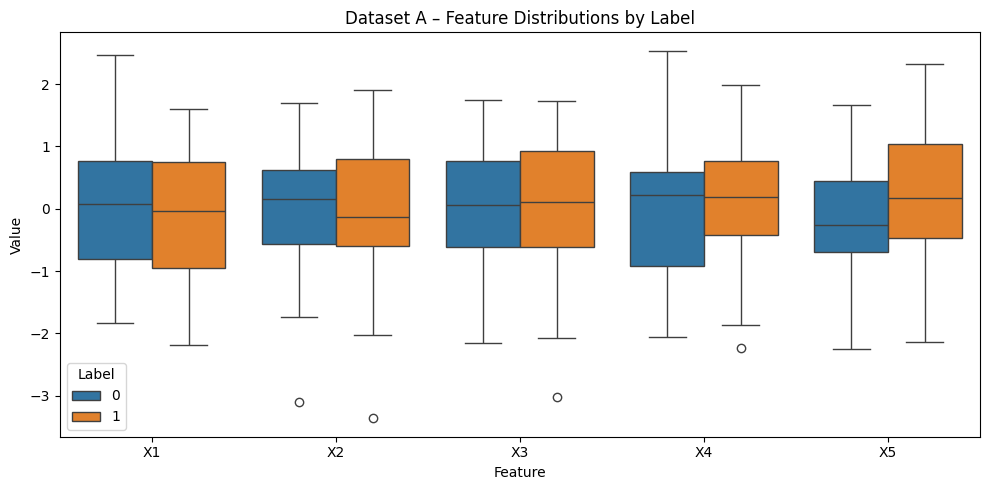

In [993]:
#Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="Feature",
    y="Value",
    hue=dataA.columns[-1],
    data=dataA_graph
)
plt.title("Dataset A – Feature Distributions by Label")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

In [995]:
dataA.index

RangeIndex(start=0, stop=100, step=1)

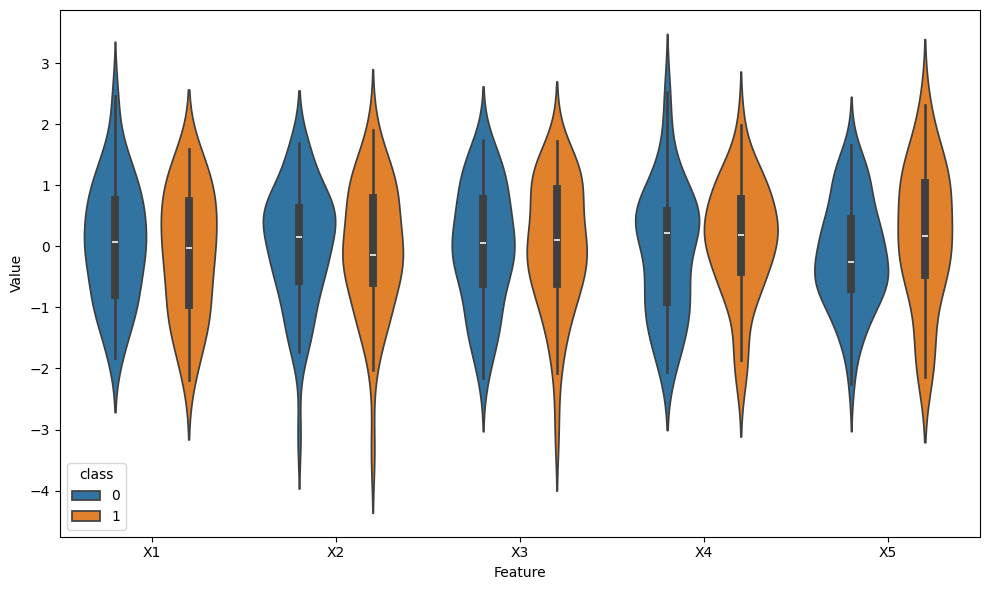

In [998]:
#Violin plot
plt.figure(figsize=(10, 6))
violinplt=sns.violinplot(data=dataA_graph, x="Feature",y="Value",hue="class",legend=True)
plt.tight_layout()
plt.show()

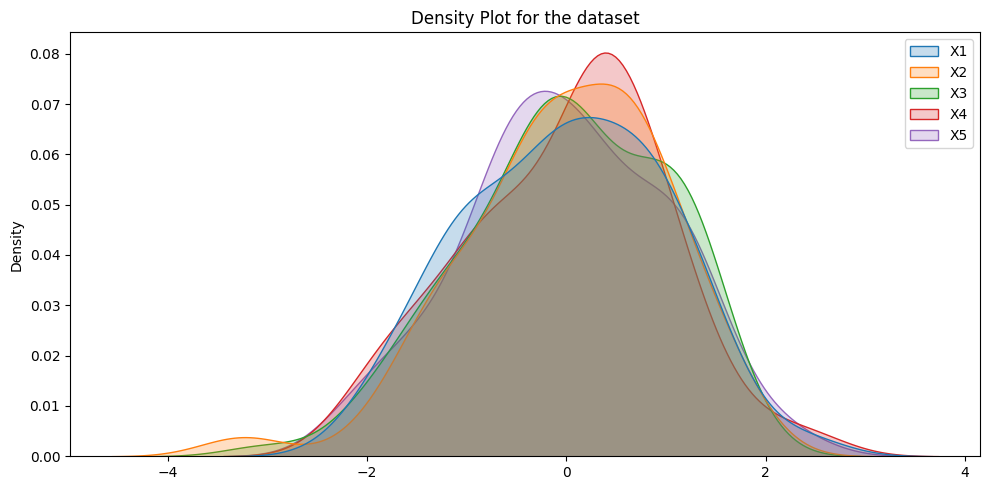

In [996]:
#Density Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=pd.DataFrame(dataA[["X1","X2","X3","X4","X5"]]),
    fill=True,
    legend=True,
)
plt.title("Density Plot for the dataset")
plt.tight_layout()
plt.show()

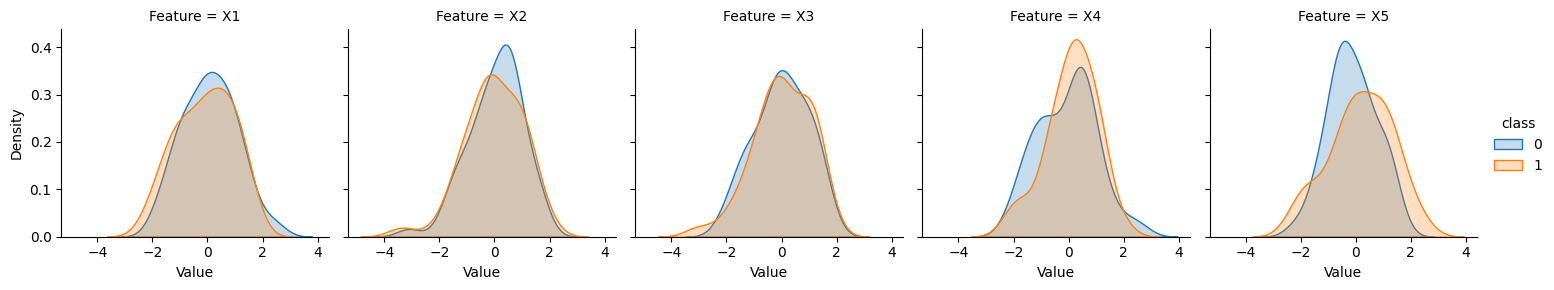

In [997]:
density_plot_with_class=sns.FacetGrid(dataA_graph, col="Feature", hue="class", col_wrap=5, sharex=True)
density_plot_with_class.map(sns.kdeplot, "Value", fill=True)
density_plot_with_class.add_legend()
plt.show()

Dataset A shows substantial overlap between class labels across all features, indicating little to no discriminative signal for effective machine learning. 
### Our hypothesis is that the model produced will be highly unstable and not generalise well. 

In [999]:
# for i, (train_index, test_index) in enumerate(skf.split(X, Y)):
#     print(train_index)
#     print(test_index)

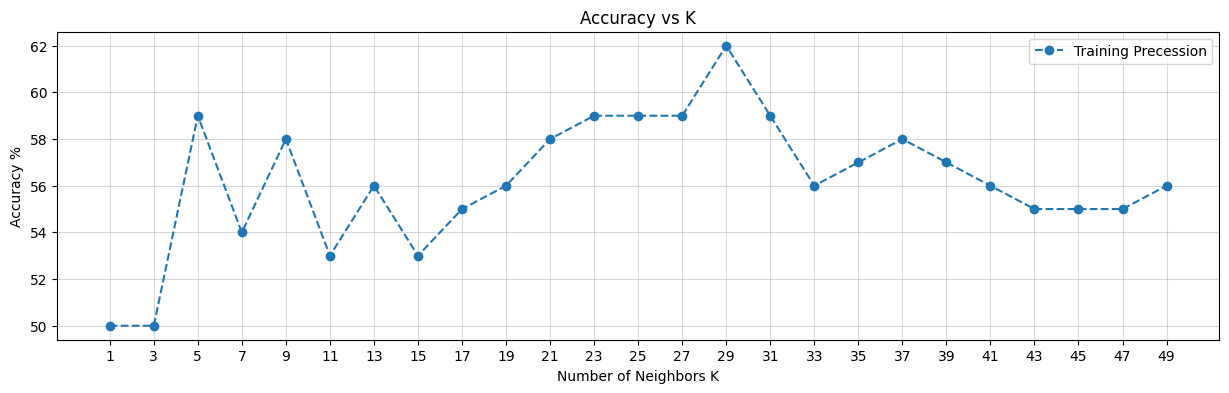

In [1000]:
X=dataA[["X1","X2","X3","X4","X5"]]
Y=dataA["class"]
k_values = range(1, 51, 2)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
model_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    #testing accuracies
    model_score= cross_val_score(model,X,Y,cv=skf,scoring="accuracy")
    model_accuracies.append(model_score.mean()*100)


plt.figure(figsize=(15,4))
plt.plot(k_values, model_accuracies, label='Training Precession', marker='o', linestyle='--')

plt.title('Accuracy vs K')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy %')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [1001]:

knn=KNeighborsClassifier(n_neighbors=5)
def run_skf_knn(knn,X,Y):
    cv_results_accuracy = cross_val_score(knn, X, Y, cv=skf, scoring='accuracy')
    cv_results_average_precision = cross_val_score(knn, X, Y, cv=skf, scoring='average_precision')
    cv_results_f1 = cross_val_score(knn, X, Y, cv=skf, scoring='f1')
    cv_results_precision = cross_val_score(knn, X, Y, cv=skf, scoring='precision')
    cv_results_recall = cross_val_score(knn, X, Y, cv=skf, scoring='recall')
    print(f"Average Precesion: {cv_results_average_precision.mean()}")
    print(f"Accuracy: {cv_results_accuracy.mean():.4f}")
    print(f"F1-score: {cv_results_f1.mean():.4f}")
    print(f"Precision: {cv_results_precision.mean():.4f}")
    print(f"Recall: {cv_results_recall.mean():.4f}")
    return skf

skf=run_skf_knn(knn,X,Y)

Average Precesion: 0.5324206349206348
Accuracy: 0.5900
F1-score: 0.4302
Precision: 0.5012
Recall: 0.4100


/Users/arya/Desktop/TERM8/COMP3202/Assignment 1/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [1002]:
#We choose K=30
skf=run_skf_knn(KNeighborsClassifier(n_neighbors=5),X,Y)


Average Precesion: 0.5324206349206348
Accuracy: 0.5900
F1-score: 0.4302
Precision: 0.5012
Recall: 0.4100


/Users/arya/Desktop/TERM8/COMP3202/Assignment 1/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


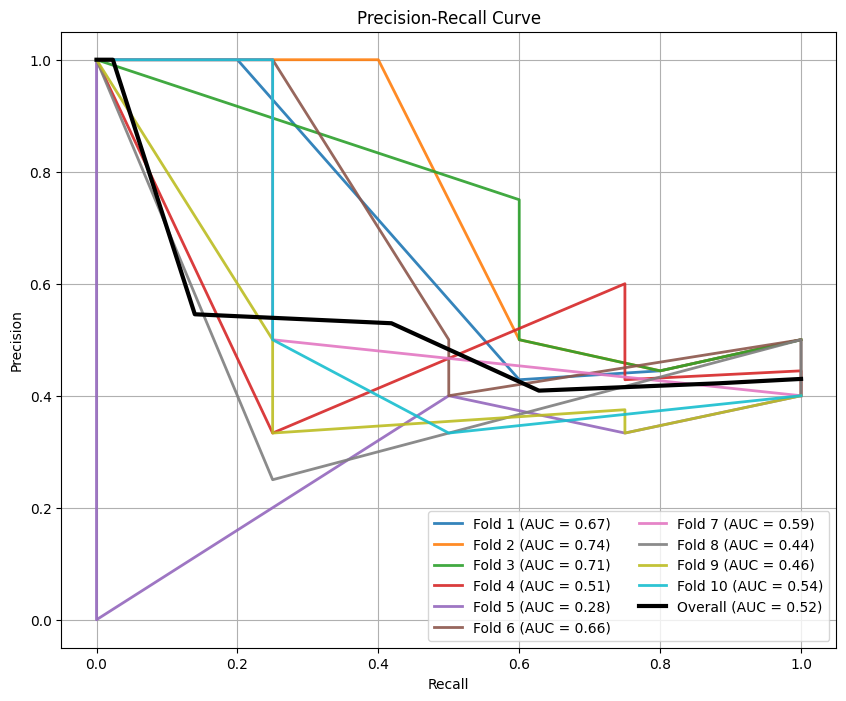

In [1003]:
def plot_pr_curve_per_fold(model, X, Y,skf):
    plt.figure(figsize=(10, 8))
    
    for i, (train_index, test_index) in enumerate(skf.split(X, Y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
        model.fit(X_train, y_train)
        y_probas = model.predict_proba(X_test)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_test, y_probas)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, lw=2, alpha=0.9, label=f'Fold {i+1} (AUC = {pr_auc:.2f})')
        # if(i==0):
        #     break

    y_probas_all = cross_val_predict(model, X, Y, cv=skf, method='predict_proba')[:, 1]
    
    precision_all, recall_all, _ = precision_recall_curve(Y, y_probas_all)
    all_auc = auc(recall_all, precision_all)
    
    #overall curve
    plt.plot(recall_all, precision_all, color='black', lw=3, label=f'Overall (AUC = {all_auc:.2f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='best', fontsize='medium', ncol=2)
    plt.grid(True)
    
    plt.show()

knn = KNeighborsClassifier(n_neighbors=5) 
plot_pr_curve_per_fold(knn, X, Y,skf)

As expected, the overall AUPRC is only 0.52 which is close to randomness. That is, our model is only performing slightly better than random choices.

In [1004]:
#Now lets test our hypothesis that only two of the 5 features are useful
X=dataA[["X4","X5"]]
Y=dataA["class"]
knn=KNeighborsClassifier()
skf=run_skf_knn(knn,X,Y)

Average Precesion: 0.5873095238095237
Accuracy: 0.5700
F1-score: 0.3996
Precision: 0.5667
Recall: 0.3300


As we can see the accuracy only goes down by 0.02 that is 2% confirming our hypothesis that the other features are not as useful. 
Now that KNN is 2D we can also plot the decession boundaries.

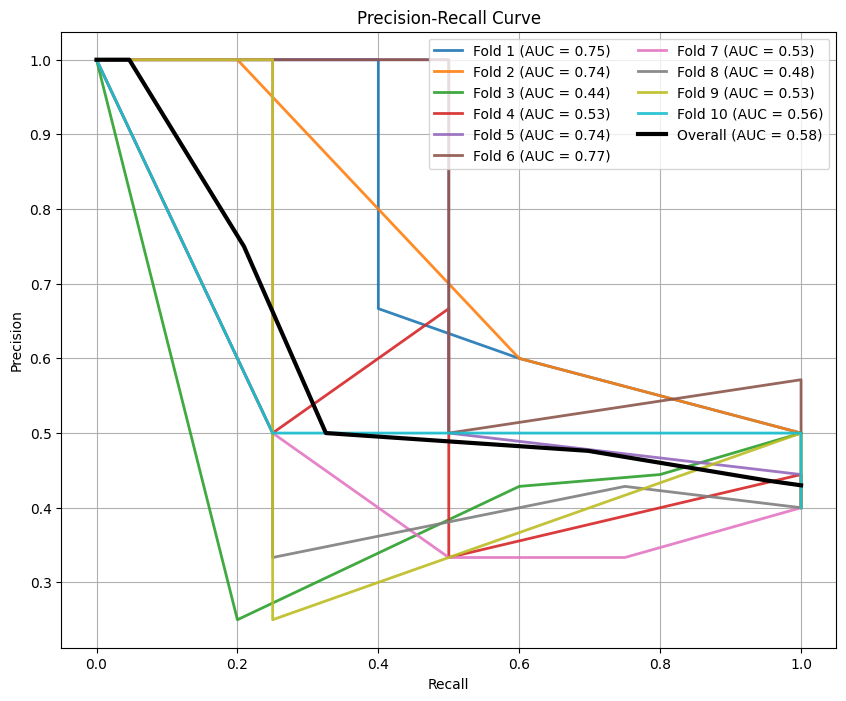

In [1005]:

knn = KNeighborsClassifier(n_neighbors=5) 
plot_pr_curve_per_fold(knn, X, Y,skf)

Dropping the overlapping features we get the above, as we can see the AUC has gone up. However, significant overlap still exists and the overall AUC is still low.
These results confirm the hypothesis that due to significant overlap we will not be able to get a stable model that generalises well. 